# Coursework 2 Part 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Classification with a Convolutional Neural Network <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
- [Task 2](#task-2): Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Importing losses, activation functions and layers from PyTorch
from torch.nn import Sequential, CrossEntropyLoss, Conv1d, MaxPool1d, Flatten, Linear, ReLU, Softmax, Parameter, Dropout
from torch.utils.data import TensorDataset, DataLoader

<a name="task-1"></a>

# Task 1: Classification with a Convolutional Neural Network [(index)](#index-task-1)

### Data Preprocessing

In this part, I will upload, reshape and standartise the data according to the requirments in the task.

In [24]:
data = pd.read_csv("data/neural_activity.csv")
data.head(100)

,Count at t=1,Count at t=2,Count at t=3,Count at t=4,Count at t=5,Count at t=6,Count at t=7,Count at t=8,Count at t=9,Count at t=10,...,Count at t=194,Count at t=195,Count at t=196,Count at t=197,Count at t=198,Count at t=199,Count at t=200,Brain Region Index,Trial Index,Trial Type
0,25,25,26,27,27,28,29,30,31,32,...,64,66,67,69,71,72,73,1,1,B
1,68,68,69,69,70,71,71,72,72,73,...,38,37,37,36,35,35,33,1,2,F
2,30,29,29,29,29,29,29,30,30,31,...,33,32,31,30,29,28,27,1,3,L
3,24,25,26,28,29,31,32,35,37,39,...,94,93,91,90,88,86,84,1,4,R
4,59,59,59,59,59,58,58,58,58,59,...,37,34,33,31,29,28,26,1,5,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,24,24,24,24,25,25,25,25,25,26,...,34,34,33,33,33,32,32,2,16,F
96,18,19,20,21,21,22,23,23,24,25,...,76,76,76,76,77,77,77,2,17,R
97,40,39,38,37,36,35,34,33,32,31,...,44,43,42,42,41,41,40,2,18,B
98,46,46,45,44,44,44,43,42,42,41,...,33,33,33,32,32,32,32,2,19,L


In [25]:
# Reshape data into N_trials by N_regions by p = 200 (length of time series)

N_regions = len(data["Brain Region Index"].unique())
N_trials = len(data["Trial Index"].unique())
print(N_regions, N_trials)

# no of features (length of the time series)
p = 200

# Drop the all columns except for the time series
count_data = data.drop(columns=[
    "Brain Region Index", 
    "Trial Index", 
    "Trial Type"])
data_arr = count_data.to_numpy()

# Reshape data
tensor = data_arr.reshape((N_regions, N_trials, p)).transpose(1,0,2)
print(tensor.shape)

test_idx = [56, 30, 42, 63, 7, 66, 2, 77, 78, 13, 39, 61, 5, 67, 70, 46]

# Get train indices
all_idx = np.arange(len(tensor))
train_idx = np.setdiff1d(all_idx, test_idx)

# Divide data into train and test
X_train = tensor[train_idx]
X_test = tensor[test_idx]

print(X_test[-1])


40 80
(80, 40, 200)
[[67 68 68 ... 64 64 65]
 [10 12 13 ... 33 33 34]
 [47 47 46 ... 48 47 47]
 ...
 [ 1  2  2 ...  5  4  4]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  2  2  1]]


In [26]:
# Standardise the data
def standardise(X, X_train=None):
    """
    Globally normalise features.

    Parameters:
        X (np.array): Feature matrix.

    Returns:
        X_norm (np.array): Normalised feature matrix
    """
    if X_train is None:
        X_train = X

    min = X_train.min()
    max = X_train.max()

    X_std = (X - min) / (max-min)

    return X_std

X_train_std = standardise(X_train)
X_test_std = standardise(X_test, X_train)
print(X_test_std[-1])

[[0.41358025 0.41975309 0.41975309 ... 0.39506173 0.39506173 0.40123457]
 [0.0617284  0.07407407 0.08024691 ... 0.2037037  0.2037037  0.20987654]
 [0.29012346 0.29012346 0.28395062 ... 0.2962963  0.29012346 0.29012346]
 ...
 [0.00617284 0.01234568 0.01234568 ... 0.0308642  0.02469136 0.02469136]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.01234568 0.01234568 0.00617284]]


In [27]:
# Label to number encoding of the trial type
label_dict = {"R":0, "L":1, "F":2, "B":3}

# Get the list of trial types in order 
# in which the trials are performed
y_str = (data.groupby("Trial Index")["Trial Type"]
            .first()
            .loc[np.arange(1, N_trials+1)]   # if trials are 1..80
            .to_numpy())

# Decode as numbers
y = np.array([label_dict[c] for c in y_str])
print(y.shape) 

# Split into train and test
y_train = y[train_idx]
y_test = y[test_idx]

classes = [0,1,2,3]
print(y_test)

(80,)
[3 2 1 0 0 3 1 2 3 0 2 0 3 0 1 2]


<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In this section, we will build a CNN classifier that takes as input a sample x
(composed of Nregions channels and p features) and outputs the probabilities $p_q$ of belonging to each class $q = 0, ..., Q − 1$ with $Q = 4$.

In [28]:
# Reproducability
torch.manual_seed(10)

# This function is taken from CNN notebook, then modified
def get_model(x_train, n_filters, k, pool_size, stride_pool, classes):
    """
    CNN model in PyTorch:
    - Layers are Conv1d(+ReLU), MaxPool1d, Flatten, Dropout and Linear(+Softmax).
    - It features an Adam optimiser and CrossEntropyLoss criterion.

    Parameters:
        x_train (np.ndarray): Training data
        n_filters (int): Number of filters to be used in the convolutional layer
        k (int): Kernel size in the convolutional layer
        pool_size (int): MaxPool1d window size
        stride_pool (int): Stride of the MaxPool1d sliding window
        classes (List): Output classes

    Returns:
        Model, criterion and optimiser.

    """

    l_out_conv = x_train.shape[2] - k + 1 # Length after Conv1d (note that the stride is 1) ## <-- EDIT THIS LINE
    l_out_pool = ((l_out_conv - pool_size) // stride_pool) + 1 # Length after MaxPool1d ## <-- EDIT THIS LINE
    l_in_linear = l_out_pool * n_filters # Size before Linear layer ## <-- EDIT THIS LINE

    model = Sequential(
        Conv1d(x_train.shape[1], n_filters, kernel_size=k),
        ReLU(), ## <-- SOLUTION
        MaxPool1d(kernel_size=pool_size, stride=stride_pool), ## <-- SOLUTION
        Flatten(), ## <-- SOLUTION
        Dropout(0.8), # added dropout
        Linear(l_in_linear, len(classes)), ## <-- SOLUTION
    )

    criterion = CrossEntropyLoss() ## <-- EDIT THIS LINE
    optimiser = torch.optim.Adam(model.parameters()) ## <-- EDIT THIS LINE

    return model, criterion, optimiser

In [29]:
n_filters = 8
k = 16
pool_size = 16
stride_pool = 4

model, criterion, optimiser = get_model(X_train, n_filters, k, pool_size, stride_pool, classes) ## <-- EDIT THIS LINE
print(model)

Sequential(
  (0): Conv1d(40, 8, kernel_size=(16,), stride=(1,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=16, stride=4, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Dropout(p=0.8, inplace=False)
  (5): Linear(in_features=344, out_features=4, bias=True)
)


In [30]:
# Numpy arrays to PyTorch tensors
x_train_tensor = torch.tensor(X_train_std, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train)
x_val_tensor = torch.tensor(X_test_std, dtype=torch.float32)
y_val_tensor = torch.tensor(y_test)

# Creating training and validation datasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor.squeeze())
val_dataset = TensorDataset(x_val_tensor, y_val_tensor.squeeze())

# Creating corresponding DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [31]:
# THis function is taken from CN notebook, then modified
def training_loop(train_loader, val_loader, max_num_epochs=200):
    """
    Training loop with early stopping to monitor the validation accuracy.

    Parameters:
        train_loader (torch.utils.data.DataLoader): Training DataLoader
        val_loader (torch.utils.data.DataLoader): Validation DataLoader
        max_num_epochs (int): Maximum number of epochs
        max_patience (int): max_patience attribute of the EarlyStopping class

    Returns:
        Model, criterion and optimiser.

    """

    history = {'training_loss': [], 'validation_loss': [], 'training_accuracy': [], 'validation_accuracy': []}
    #early_stopping = EarlyStopping(max_patience=max_patience)

    for epoch in range(max_num_epochs):

        tr_loss = 0.0
        tr_correct = 0
        val_loss = 0.0
        val_correct = 0

        # Training
        model.train()
        for inputs, labels in train_loader:
            optimiser.zero_grad() # Setting gradients to zero
            outputs = model(inputs)
            loss = criterion(outputs, labels) ## <-- EDIT THIS LINE
            tr_loss += loss.item()
            tr_correct += (outputs.argmax(dim=1) == labels).sum().item() ## <-- EDIT THIS LINE
            loss.backward() # Computes gradients of the loss
            optimiser.step() # Optimisation step (parameters are updated)

        history['training_loss'].append(tr_loss/len(train_loader))
        history['training_accuracy'].append(100*tr_correct/len(train_dataset))

        # Validation
        model.eval()
        with torch.no_grad():
            for inputs_v, labels_v in val_loader:
                outputs_v = model(inputs_v)
                loss_v = criterion(outputs_v, labels_v) ## <-- EDIT THIS LINE
                val_loss += loss_v.item()
                if labels_v.size(0):
                    val_correct += (outputs_v.argmax(dim=1) == labels_v).sum().item() ## <-- EDIT THIS LINE

        history['validation_loss'].append(val_loss/len(val_loader))
        history['validation_accuracy'].append(100*val_correct/len(val_dataset))

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1}/{max_num_epochs}, Training loss: {tr_loss/len(train_loader)}, Training accuracy: {100*tr_correct/len(train_dataset)}%, Validation loss: {val_loss/len(val_loader)}, Validation accuracy: {100*val_correct/len(val_dataset)}%')
    return history


In [32]:
# Calling the training loop
max_num_epochs = 100

history = training_loop(train_loader, val_loader, max_num_epochs)

Epoch 1/100, Training loss: 1.3968418538570404, Training accuracy: 26.5625%, Validation loss: 1.3807313442230225, Validation accuracy: 31.25%
Epoch 10/100, Training loss: 1.1858224868774414, Training accuracy: 35.9375%, Validation loss: 1.1173615455627441, Validation accuracy: 50.0%
Epoch 20/100, Training loss: 0.7248862981796265, Training accuracy: 71.875%, Validation loss: 0.7391302585601807, Validation accuracy: 81.25%
Epoch 30/100, Training loss: 0.3481357544660568, Training accuracy: 90.625%, Validation loss: 0.3552129864692688, Validation accuracy: 93.75%
Epoch 40/100, Training loss: 0.21469605714082718, Training accuracy: 93.75%, Validation loss: 0.24535751342773438, Validation accuracy: 93.75%
Epoch 50/100, Training loss: 0.16402874514460564, Training accuracy: 98.4375%, Validation loss: 0.16579778492450714, Validation accuracy: 93.75%
Epoch 60/100, Training loss: 0.11968662776052952, Training accuracy: 96.875%, Validation loss: 0.12811525166034698, Validation accuracy: 93.75%


In [33]:
# Predict trial types
test_preds = torch.softmax(model(torch.tensor(X_test_std, dtype=torch.float32)), dim=1).detach().numpy() 
hard_preds_test = test_preds.argmax(axis=1)

train_preds = torch.softmax(model(torch.tensor(X_train_std, dtype=torch.float32)), dim=1).detach().numpy() 
hard_preds_train = train_preds.argmax(axis=1)

In [34]:
# Compute models accuracy
def accuracy(y_true, y_pred):
    bin = np.where(y_true==y_pred, 1, 0)
    return np.mean(bin)

train_acc = accuracy(y_train, hard_preds_train)
test_acc = accuracy(y_test, hard_preds_test)
print(f"training accuracy: {train_acc}, test accuracy: {test_acc}")

training accuracy: 1.0, test accuracy: 0.9375


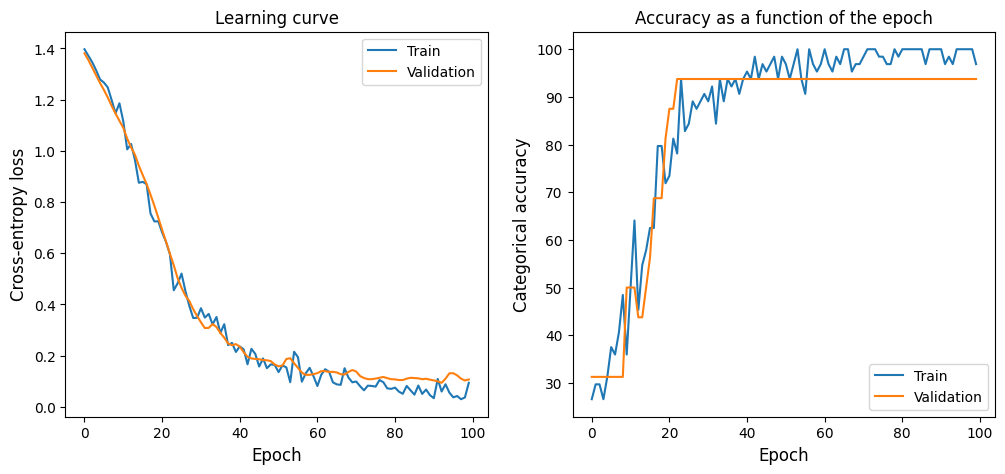

In [35]:
# Plot the learning curves

fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)
plt.plot(history['training_loss'], label='Train')
plt.plot(history['validation_loss'], label='Validation')
plt.xlabel('Epoch', size=12)
plt.ylabel('Cross-entropy loss', size=12)
plt.title('Learning curve')
plt.legend()

fig.add_subplot(122)
plt.plot(history['training_accuracy'], label='Train')
plt.plot(history['validation_accuracy'], label='Validation')
plt.xlabel('Epoch', size=12)
plt.ylabel('Categorical accuracy', size=12)
plt.title('Accuracy as a function of the epoch')
plt.legend()

plt.show()

The model performs extremely well with training accuracy of 100% and test accuracy of 93.75%. The learning curve for both training and validation loss decays steadily, with training and validation being more or less the same. Similarly, the accuracy is similar for both training and validation sets, with validation going up to 93.75% right after the 20th epoch and not moving after that. However, the loss still goes down at a high rate up until epoch 40, where it slows down. 

There is no overfitting, but perhabs we could've saved a little bit of time by applying early stopping, tho this is not critical.

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In this section we will evaluate the model in training mode by predicting the classification probabilities for the test data 10 times while the model is in training mode.

In [36]:
# Keep model in training mode
model.train()

# Initialise probabilities
probs = torch.zeros(10, y_test.shape[0], len(classes))

# Run 10 times and compute probabilities every time and store them
for i in range(10):
    with torch.no_grad():
        logits = model(x_val_tensor)
        probs[i] = torch.softmax(logits, dim=1)
probs.shape

torch.Size([10, 16, 4])

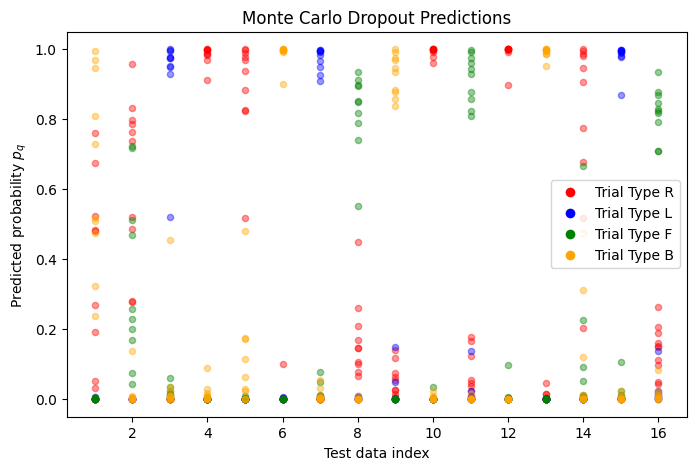

In [ ]:
probs_np = probs.cpu().numpy()  # convert from torch

# Plot results
runs, N_test, Q = probs_np.shape
x = np.arange(1, N_test+1)
colors = ["red", "blue", "green", "orange"]

# reverse mapping
label_map = {0:"R", 1:"L", 2:"F", 3:"B"}

# handles for the legend
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[q],
        markersize=8,
        label=f"Trial Type {label_map[q]}"
    )
    for q in range(Q)
]

plt.figure(figsize=(8,5))
for q in range(Q):
    for i in range(runs):
        label = label_map[q] if i == 0 else None  # label only once
        plt.scatter(
            x,
            probs_np[i, :, q],
            color=colors[q],
            alpha=0.4,
            s=20,
            label=label
        )

plt.xlabel("Test data index")
plt.ylabel("Predicted probability $p_q$")
plt.legend(handles = handles)
plt.title("Predicted probabilities with Dropout")
plt.show()

Since our model stays in training mode, the droupout layer remains active during all the 10 predictions. the Droupout layer has quite a high parameter - 0.8 - meaning that each neuron has a 0.8 probability of getting deactivated. On average, 80% of the neurons will be set to 0, meaning the model essentially makes predictions using somewhat different subnetworks. COnsequently, we get different probability predictions which helps us get an idea about model's uncertainty.

From the graph we can see that the model is a lot more certain about some data points compared to others. While all the data points have clusters of certain coloured points at the top of the graph (at probability near 1, meaning the model consistently chooses one trial type to be most probable) and multicolour clusters around zero (meaning the model is certain that the trial does not belong to those other types), some data points have quite a bit of overlap. We clearly see that the model is most uncertain about the points 1, 2, 14, so we should treat these predictions with causion, while we can trust the rest of redictions, because they are consistent even if we only employ a small random part of the network.

We also notice that the model is leat certain about assiging trial type "F" (forward), since it only reaches probability 1 for 1 data point, while the other types cluster right near 1 a lot more. This could be due to underrepresentation in the training set or just this type of trial being harder to identify based on the brain activity.

<a name="task-2"></a>

# Task 2: Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation [(index)](#index-task-2)

In [38]:
# Normalise data
X = standardise(data_arr)
X.shape

(3200, 200)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

In [39]:
## EDIT HERE
def euclidean_cost_norm(X, W, H):
    """
    Computes the Euclidean NMF cost function.

    Parameters:
      X (np.ndarray): Data matrix, shape (N, p).
      W (np.ndarray): Weight matrix, shape (N, r).
      H (np.ndarray): Feature matrix, shape (r, p).

    Returns:
      cost_value (float): Value of the cost function.
    """

    # Check that W and H can be multiplied together
    assert W.shape[1] == H.shape[0], "The inner dimensions of W and H do not match for multiplication."

    # Test to see whether the size of X and the size of W times H matches
    assert X.shape == (W.shape[0], H.shape[1]), "The dimensions of X do not match the dimensions of WH."

    # compute the difference between X and the matrix product of W and H
    diff = X - W @ H ## <-- SOLUTION

    # Compute the Euclidean distance-baosed cost function
    cost_value = (diff * diff).sum() ## <-- SOLUTION
    cost_value_normalised = cost_value / (X * X).sum()
    return cost_value_normalised

In [40]:
# EDIT THIS FUNCTION
def euclidean_NMF(X, r, rng, epsilon=0.0001, n_iters=500):
  """
  Implements NMF with the euclidean cost function.

  Parameters:
    X (np.ndarray): Data matrix, shape (N, p).
    r (int): Number of components.
    rng (np.random.default_rng): Random number generator.
    epsilon (float): Small positive scalar, default 0.0001.
    n_iters (int): Number of iterations, default 500.

  Returns:
    W (np.ndarray): Weight matrix, shape (N, r).
    H (np.ndarray): Feature matrix, shape (r, p).
    cost_values (list): List of cost values for each iteration.
  """
  # N x r components matrix, usually interpreted as the weights of each feature
  W = rng.random((X.shape[0], r))
  # r x P matrix interpreted as the basis set
  H = rng.random((r, X.shape[1]))

  # empty list
  cost_values = []

  # loop over the n iterations
  for i in range(n_iters):
      # compute the update on W
      W = W * (X @ H.T) / (W @ H @ H.T + epsilon) ## <-- SOLUTION
      # compute the update on H
      H = H * (W.T @ X) / (W.T @ W @ H + epsilon) ## <-- SOLUTION
      # compute the cost and append to list
      cost_values.append(euclidean_cost_norm(X, W, H))
      if i % 50 == 0 or i == n_iters - 1:
        print(f"Iteration {i:5d} | Loss: {euclidean_cost_norm(X, W, H):10.4e}")

  return W, H, cost_values

In [41]:
r = 5
eps = 0.0001
n_iters = 500
rng = np.random.default_rng(0)
W, H, cost_values = euclidean_NMF(X, r, rng)

Iteration     0 | Loss: 2.0629e-01
Iteration    50 | Loss: 3.3378e-02
Iteration   100 | Loss: 3.0872e-02
Iteration   150 | Loss: 3.0255e-02
Iteration   200 | Loss: 2.9988e-02
Iteration   250 | Loss: 2.9867e-02
Iteration   300 | Loss: 2.9806e-02
Iteration   350 | Loss: 2.9770e-02
Iteration   400 | Loss: 2.9749e-02
Iteration   450 | Loss: 2.9734e-02
Iteration   499 | Loss: 2.9725e-02


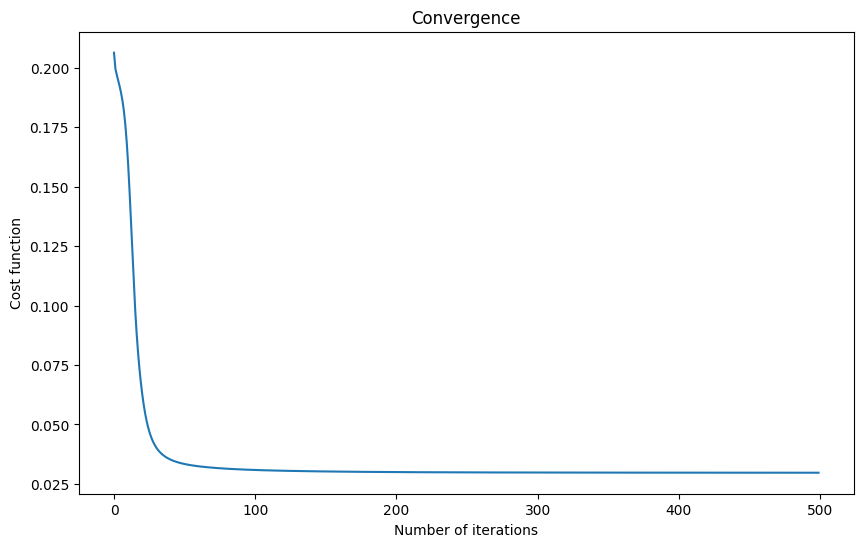

In [42]:
plt.figure(figsize=(10,6))
plt.plot(cost_values)
plt.xlabel('Number of iterations')
plt.ylabel('Cost function')
plt.title('Convergence')
plt.show()

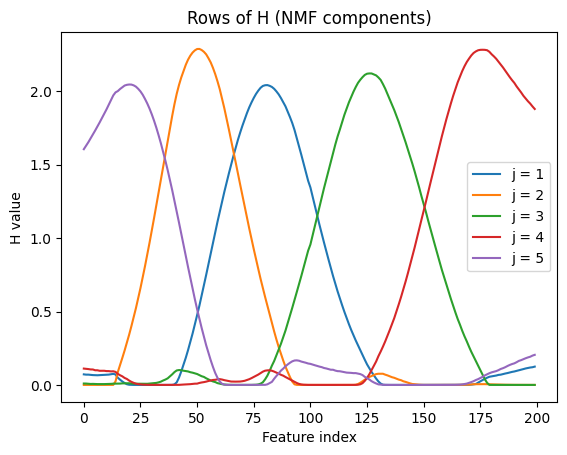

In [43]:
r, p = H.shape

plt.figure()

for k in range(r):
    plt.plot(range(p), H[k, :], label=f"j = {k+1}")

plt.xlabel("Feature index")
plt.ylabel("H value")
plt.title("Rows of H (NMF components)")
plt.legend()
plt.show()

The graph shows the 5 rows of H as a function of time (our feature space is the 200 timestamps long time series). The rows of H are the components that explain the time periods (features) of the neural activity ( our data).

We can clearly see that each component has a spike around a particular time window, the spikes are more or less evenly spaced and cover the whole feature space, suggesting that the decomposition into 5 components works extremely well - each component explains a particular time window and together the 5 completely cover the feature space.

The decomposition suggests that the neural activity during the tasks can be decomposed into a sequence of distinct motifs ( in our case - 5 components), and the neural activity of a brain region can be represented as a non-negative combination of these components.

This decomposition also allows us to treat the components as time windows. THey have the following order: 5, 2, 1, 3, 4.

2(b)

/var/folders/z9/c4qhll5j4d1_vdj8tbv7xnfw0000gn/T/ipykernel_29921/2949587237.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


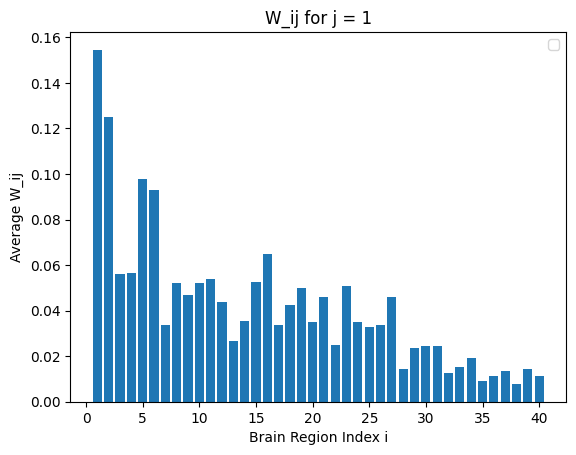

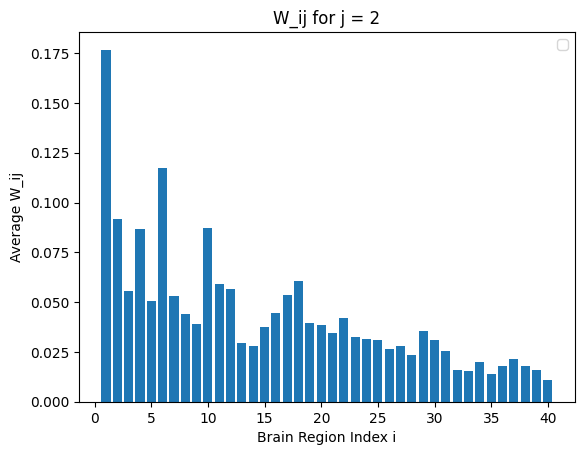

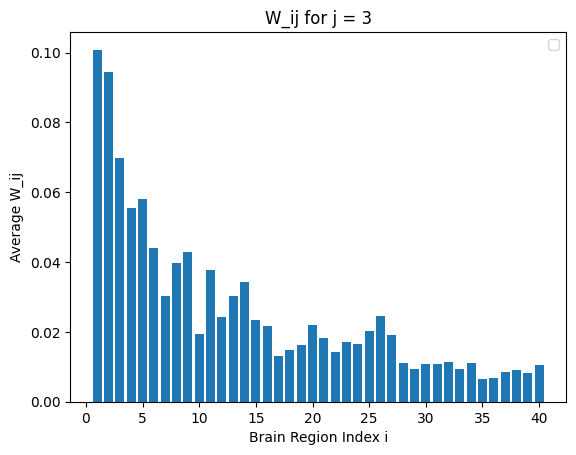

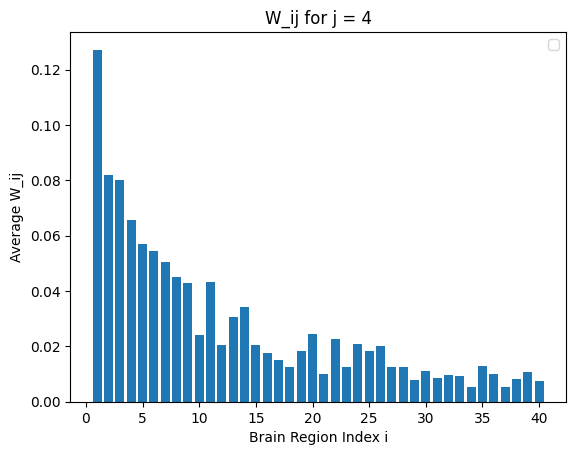

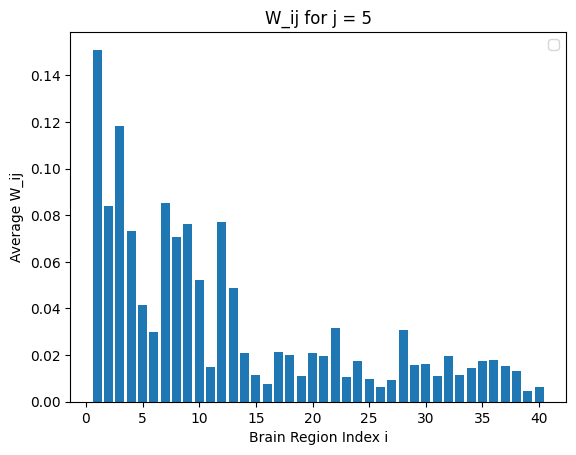

In [44]:
for j in range(r):
    W_j = W[:, j].reshape(N_regions, N_trials)
    W_regions = W_j.mean(axis=1)
    plt.bar(np.arange(1, N_regions+1), W_regions)
    plt.xlabel("Brain Region Index i")
    plt.ylabel("Average W_ij")
    plt.title(f"W_ij for j = {j+1}")
    plt.legend()
    plt.show()

These plots show the average weight per brain region for each of the 5 components. The first thing we notice is that for all components (ie time periods) the weights generally decrease as we move across Brain Regions. This is exactly what is expected, since in the dataset the "brain regions indices are ordered according to the magnitude of their neural activity (i.e., of their spiking neurons’ counts integrated over time steps and trials), with index 1 corresponding to the highest activity
level."

Another interesting observation concerns the y-scale of the graphs. We see that on average, the weights are highest for components 1 and 2, while components 3 and 4 have the lowest average weights ( I judge by the y-scale, since the absolute average hight of bars within a graph is more or less the same across graphs, but the scales differ). If we go back to the plot in part (a) and look at what time periods the components correspond to, we see that components 1 and 2 correspond to the middle of the time series, while 3 and 4 are at the end of the time series. This suggests that on average the primates's brain activity is moderate at the begginning of a task, highest in the middle and then it fades off at the end (they complete the task or get bored).

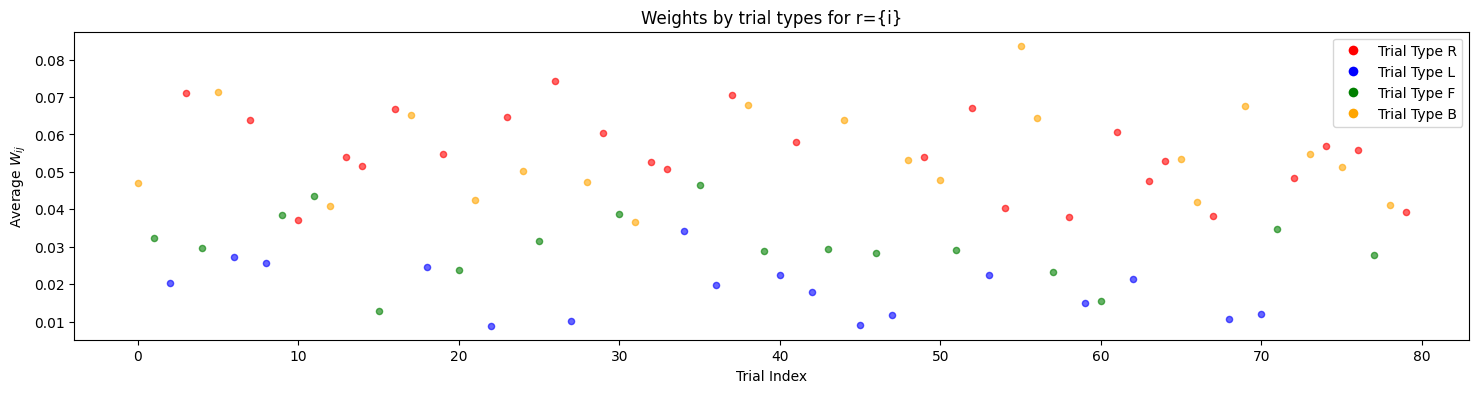

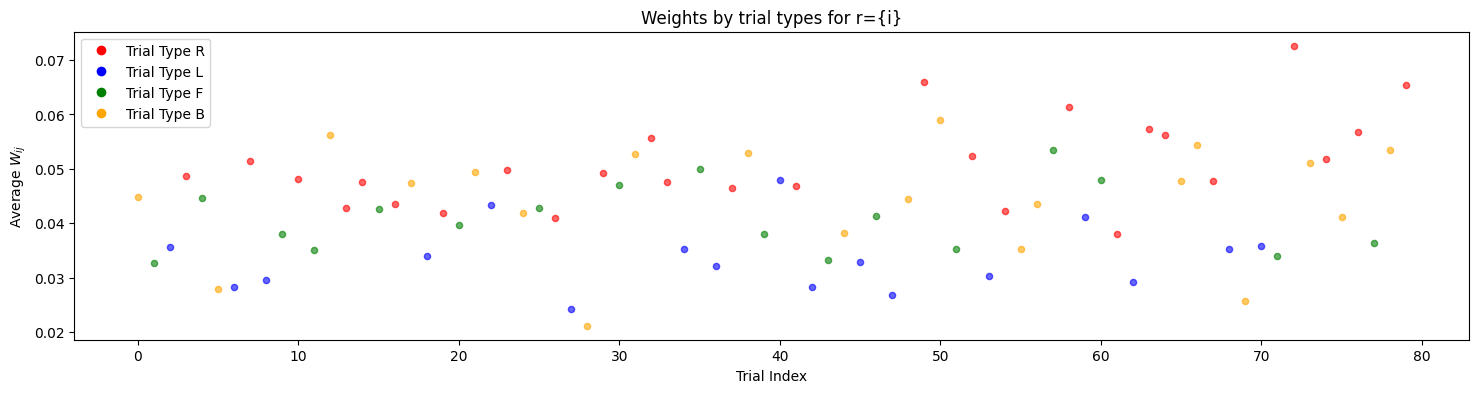

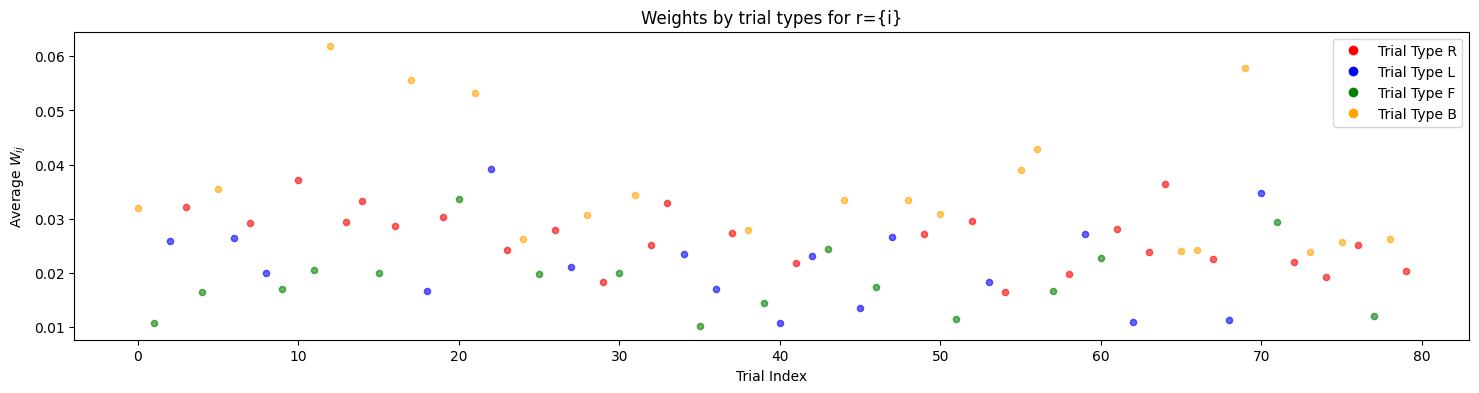

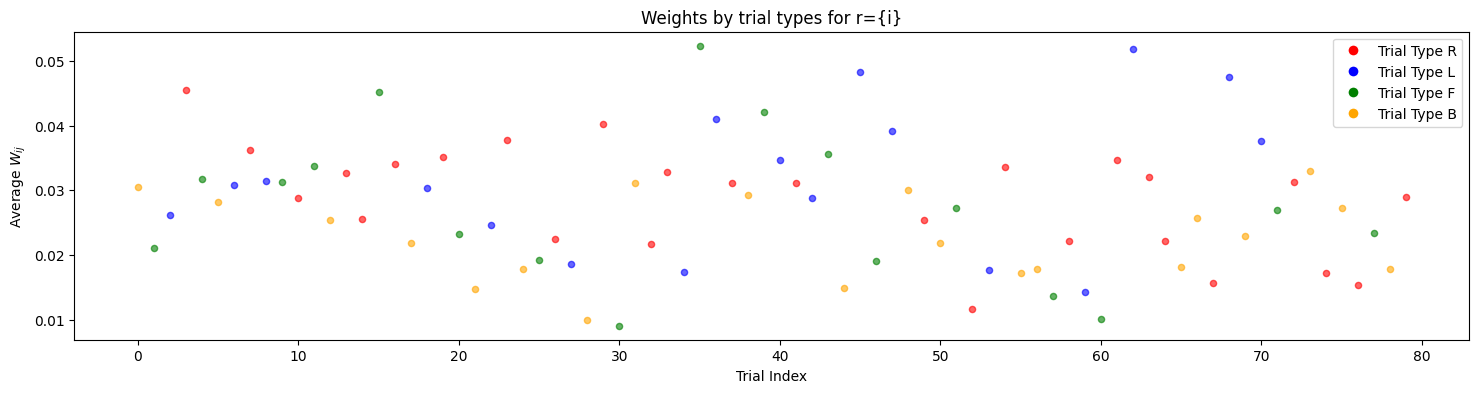

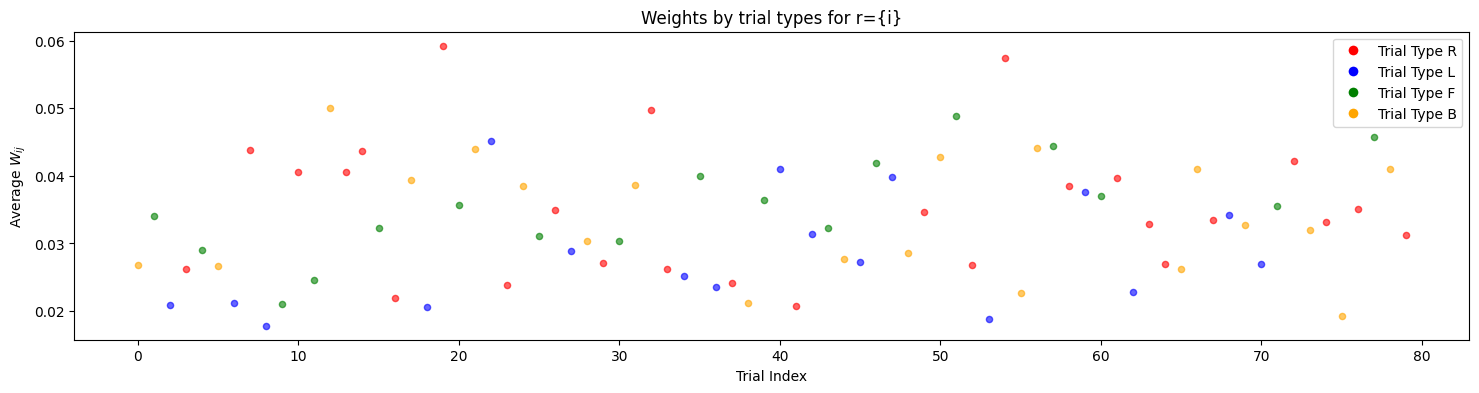

In [48]:
for j in range(r):
    W_j = W[:, j].reshape(N_regions, N_trials)
    W_trials = W_j.mean(axis=0)

    plt.figure(figsize=(18, 4))
    for i in range(W_trials.shape[0]):
        plt.scatter(
            i,
            W_trials[i],
            color=colors[y[i]],
            alpha=0.6,
            s=20
        )

    plt.xlabel("Trial Index")
    plt.ylabel("Average $W_{ij}$")
    plt.title("Weights by trial types for r={i}")
    plt.legend(handles=handles)
    plt.show()

In these graphs, we averaged the weights over the brain regions and plotted the weights for different trial types.

While one could try to identify some patterns (eg for j = 1, it seems like turning left requires the least about of brain activity, while turning backwards - the most), the patterns are not consistent over time (different js imply different time periods) and they are not easlity explainable (why would turning left require more brain activity in the middle of that action than turning backwards? Shouldn't turning left and right be consistently of the same difficulty?) and given the high variance of the data, we cannot conclude that those "patterns" are statistically significant.

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

In [50]:
def NMTF(X, r1, r2, rng, epsilon=1e-4, n_iters=500):
    """
    Implements NMTF with the normalised Euclidean cost function.

    Parameters:
        X (np.ndarray): Data matrix, shape (N, p).
        r1 (int): Number of row clusters/components.
        r2 (int): Number of column clusters/components.
        rng (np.random.Generator): Random number generator.
        epsilon (float): Small positive scalar, default 1e-4.
        n_iters (int): Number of iterations, default 500.

    Returns:
        U (np.ndarray): Shape (N, r1)
        S (np.ndarray): Shape (r1, r2)
        V (np.ndarray): Shape (p, r2)
        cost_values (list): List of cost values for each iteration.
    """
    N, p = X.shape

    U = rng.random((N, r1))
    S = rng.random((r1, r2))
    V = rng.random((p, r2))

    cost_values = []

    for i in range(n_iters):
        U = U * ((X @ V @ S.T) / (U @ S @ V.T @ V @ S.T + epsilon))
        V = V * ((X.T @ U @ S) / (V @ S.T @ U.T @ U @ S + epsilon))
        S = S * ((U.T @ X @ V) / (U.T @ U @ S @ V.T @ V + epsilon))

        # X ≈ U S V^T
        cost = euclidean_cost_norm(X, U, S @ V.T)
        cost_values.append(cost)

        if i % 50 == 0 or i == n_iters - 1:
            print(f"Iteration {i:5d} | Loss: {cost}")

    return U, S, V, cost_values

In [51]:
r1 = 7
r2 = 5
eps = 1e-7
n_iters = 500
U, S, V, cost_values_nmtf = NMTF(X, r1, r2, rng, epsilon=eps)

Iteration     0 | Loss: 0.19396454435643098
Iteration    50 | Loss: 0.10673331167819299
Iteration   100 | Loss: 0.07155191175136642
Iteration   150 | Loss: 0.05013163048782687
Iteration   200 | Loss: 0.04803465403033871
Iteration   250 | Loss: 0.04721588504720998
Iteration   300 | Loss: 0.04642003359116814
Iteration   350 | Loss: 0.040965459999315695
Iteration   400 | Loss: 0.0340038626519428
Iteration   450 | Loss: 0.03225233128102944
Iteration   499 | Loss: 0.03150673254542065


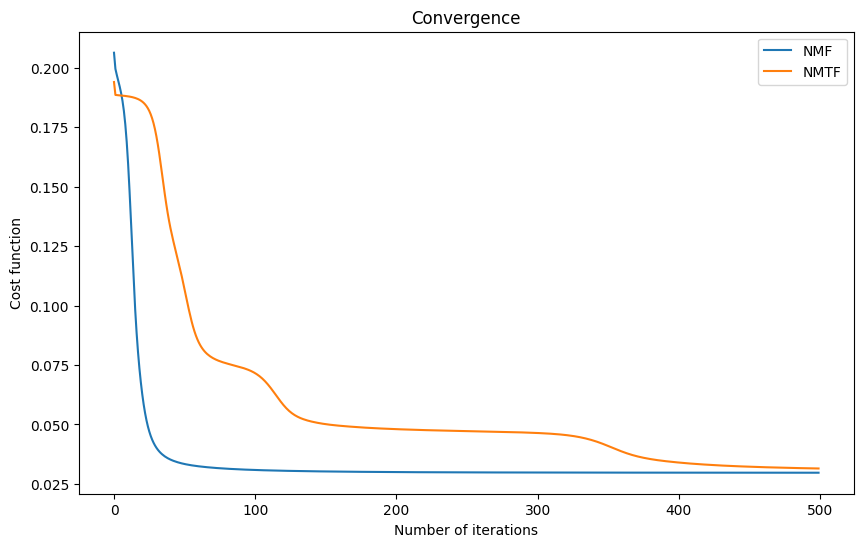

In [52]:
plt.figure(figsize=(10,6))
plt.plot(cost_values, label="NMF")
plt.plot(cost_values_nmtf, label="NMTF")
plt.xlabel('Number of iterations')
plt.ylabel('Cost function')
plt.legend()
plt.title('Convergence')
plt.show()

The plot shows that NMFT learns slower, with the loss functions being consistently higher for NMFT compared to NMT. However, by the end of the 500 iterations, they do converge to almost the same value of about 0.025 (with NMT still being lower).

Therefore, the two implementations have similar power, but NMFT takes longer to converge (perhabs due to being way more complicated). The more complicated structure of NMFT does not pay off in lower cost function. 

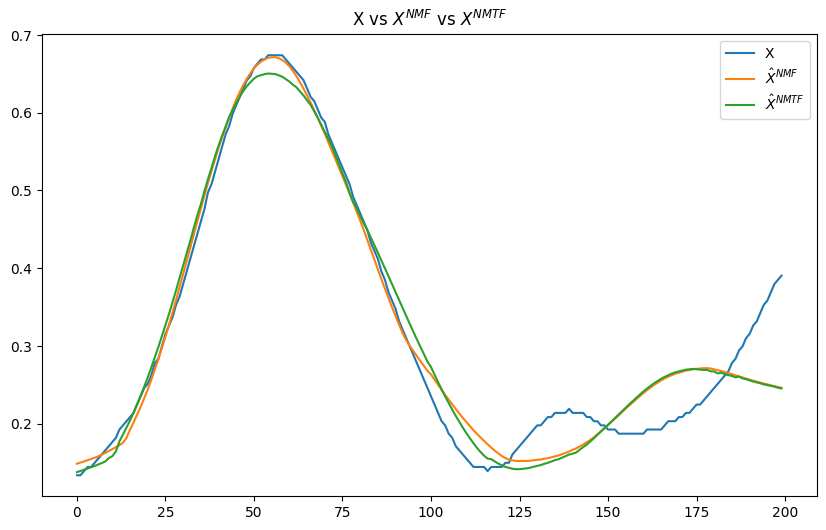

In [53]:
X_nmf = W @ H
X_nmtf = U @ S @ V.T

plt.figure(figsize=(10,6))
plt.plot(X[0], label="X")
plt.plot(X_nmf[0], label="$\hat{X}^{NMF}$")
plt.plot(X_nmtf[0], label="$\hat{X}^{NMTF}$")
plt.title("X vs $X^{NMF}$ vs $X^{NMTF}$")
plt.legend()
plt.show()

NMF and NMTF have a very similar (virtually the same) trajectory, which follows X very closely for $t \in [0, 100]$. After that, the trajectories of both predictions follow the trajectory of true X with a significant delay, so both do not perform well for $t \in [125, 200]$.

A closer inspection reveals that at the top of the first spike ($t \approx 55$) NMF performs better than NMTF. Additionaly, for $ t \in [85, 100]$ we also see that NMF follows the true X exactly, while NMTF is slightly off.

Overall, NMTF did not improve the performance.

It is worth noting that tuning the hyperparameters for both models might improve the performance, expecially for NMTF, since, as we will see from the next graphs, dimentionality reduction does not work as well in NMTF as it does for NMF, which might be due to the wrong amount of dimentions chosen.

Text(0.5, 1.0, 'Heatmap of connection matrix S (7 by 5)')

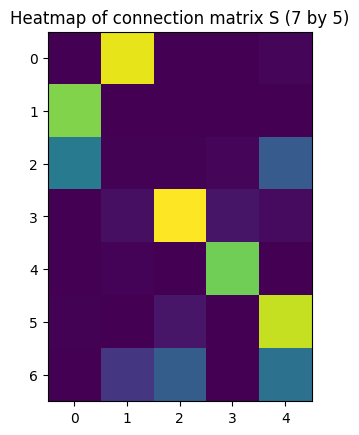

In [54]:
plt.imshow(S)
plt.title("Heatmap of connection matrix S (7 by 5)")

S is the connecting matrix between U and V, so the ij-th entry of S represents the strenth of the interaction of ith column of U with the jth row of V, where V is responsible for the time periods clustering as before, and U presents clusters of recordings (that might share simialr behaviour somehow). 

In the heatmap, yellow represents stronger connections, while purple - weaker connections. We notice that the strongest interaction happens between column 3 of U and row 2 of V.

In general, we see that most rows of V have a very strong connection with one column of U and very little with the others. This partially motivates only chooing those columns with maximal interaction in part e. 

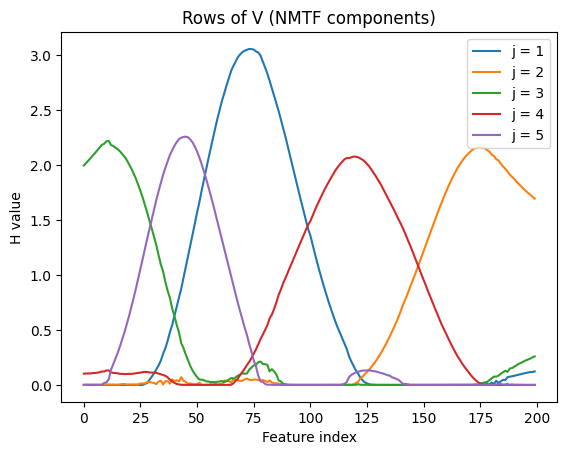

In [55]:
r2, p = V.T.shape

plt.figure()

for k in range(r2):
    plt.plot(range(p), V.T[k, :], label=f"j = {k+1}")

plt.xlabel("Feature index")
plt.ylabel("H value")
plt.title("Rows of V (NMTF components)")
plt.legend()
plt.show()

In [57]:
Sns = np.argmax(S, axis=0)
print(Sns)

[1 0 3 4 5]


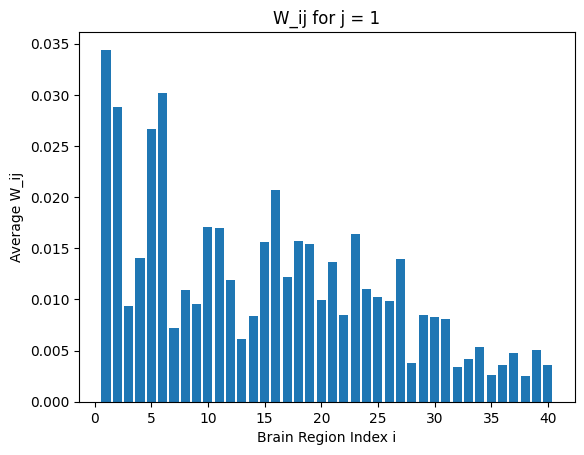

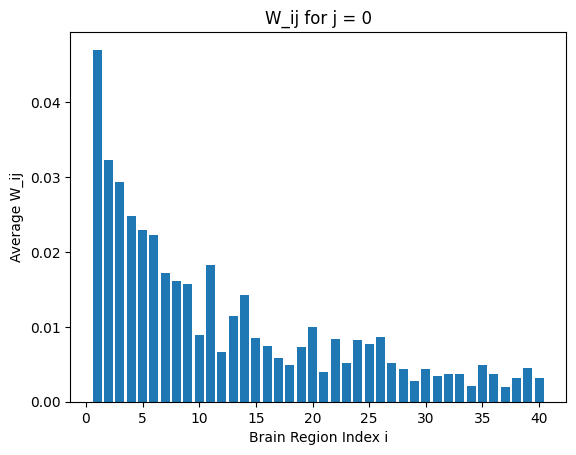

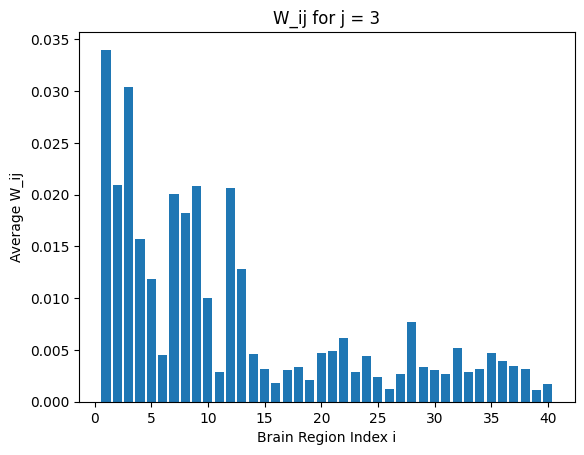

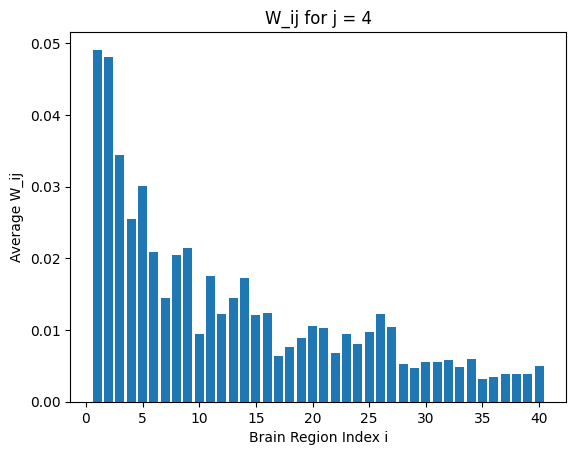

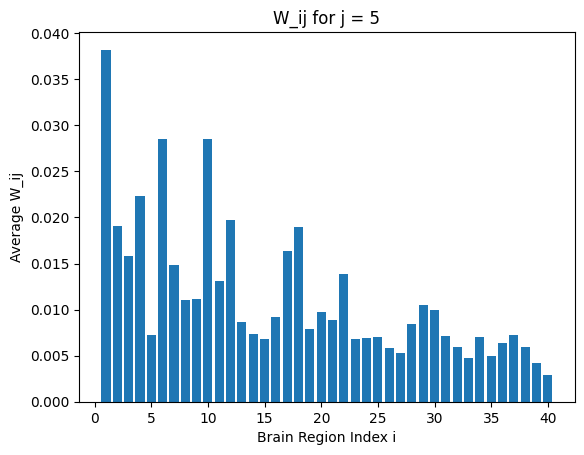

In [58]:
for j in Sns:
    U_j = U[:, j].reshape(N_regions, N_trials)
    U_regions = U_j.mean(axis=1)
    plt.bar(np.arange(1, N_regions+1), U_regions)
    plt.xlabel("Brain Region Index i")
    plt.ylabel("Average W_ij")
    plt.title(f"W_ij for j = {j}")
    plt.show()

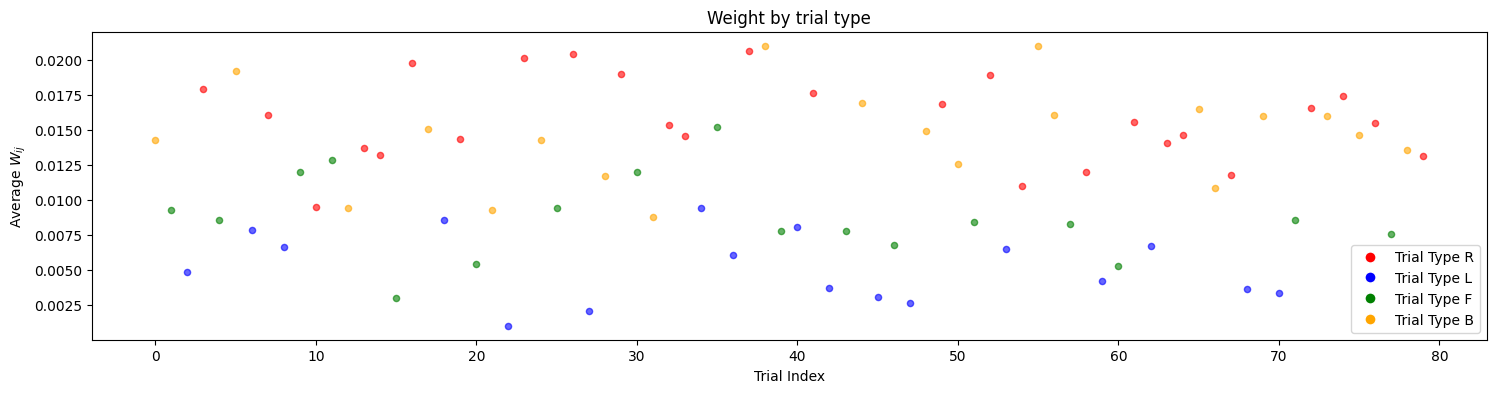

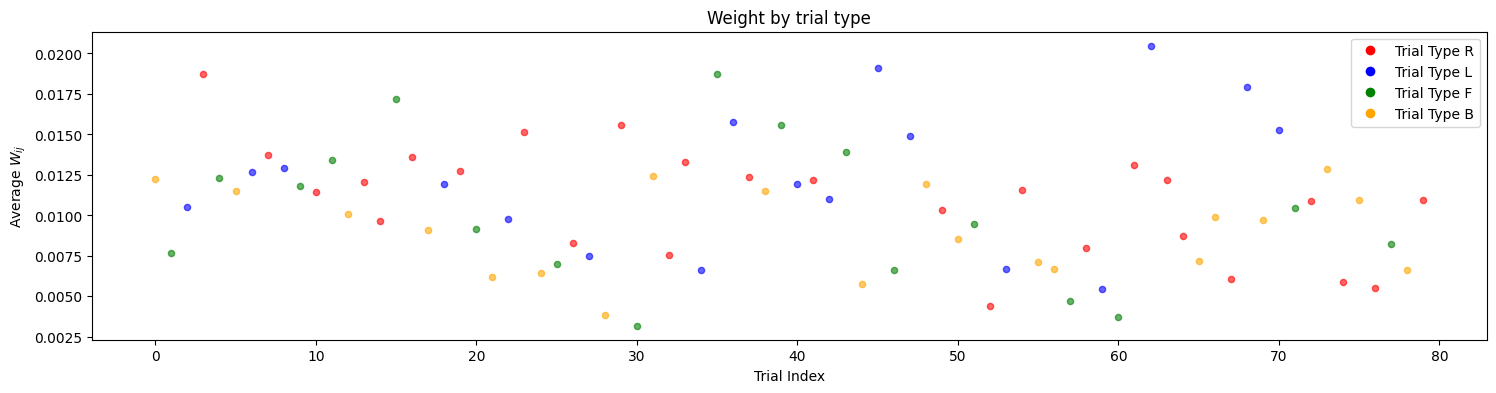

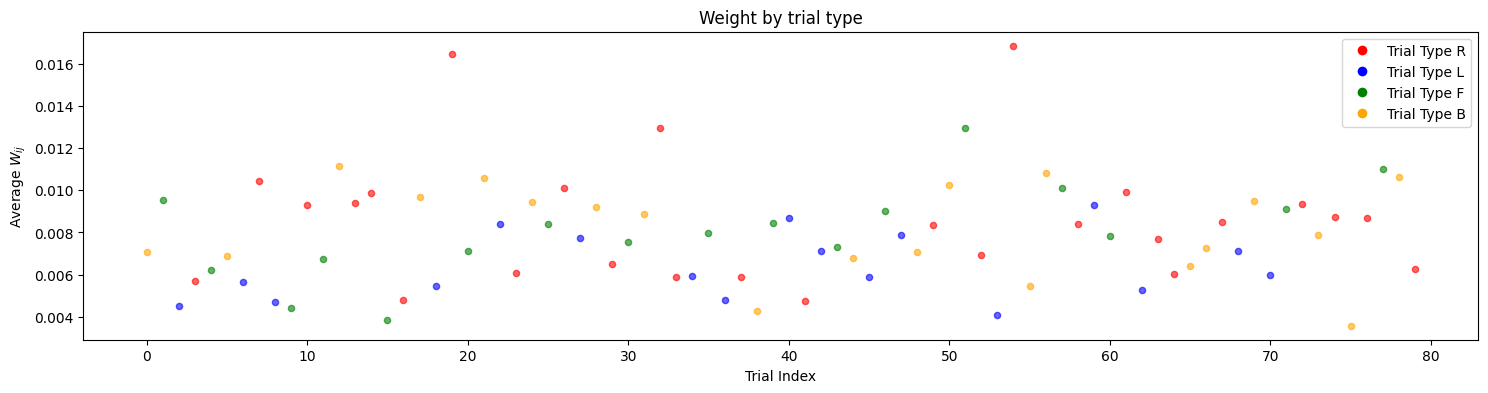

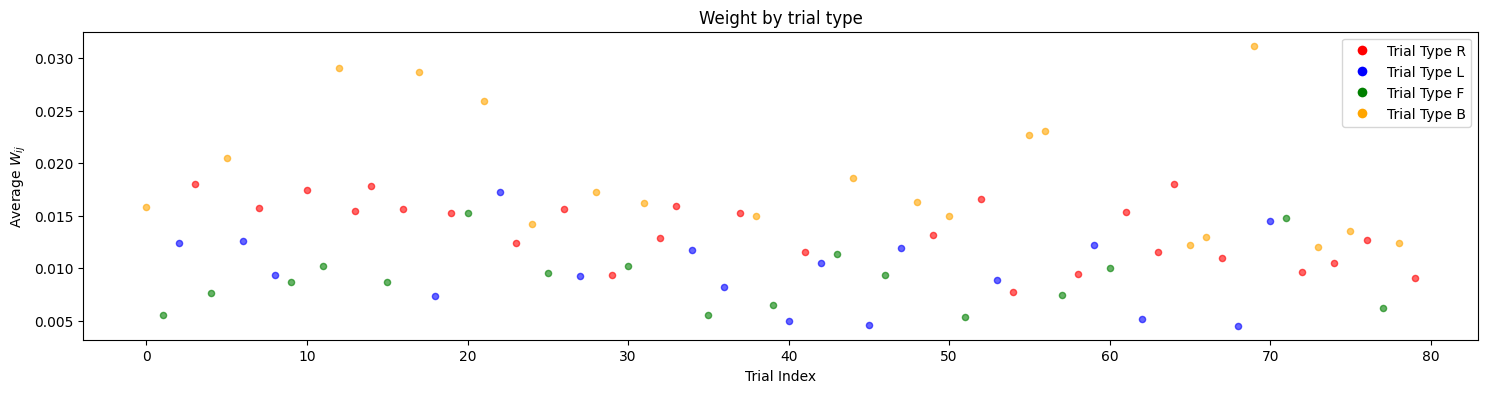

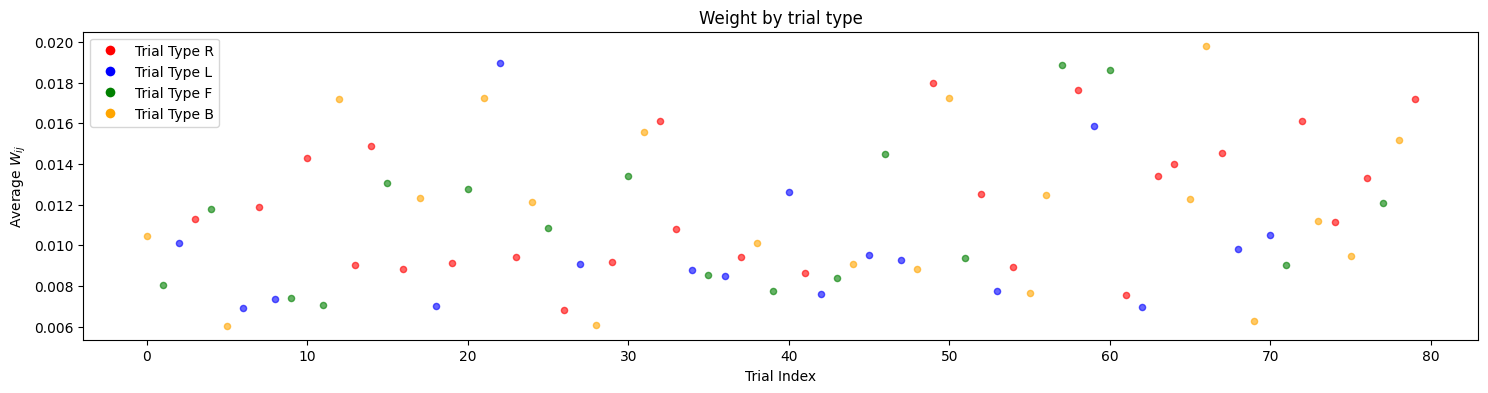

In [59]:
for j in Sns:
    U_j = U[:, j].reshape(N_regions, N_trials)
    U_trials = U_j.mean(axis=0)

    plt.figure(figsize=(18, 4))
    for i in range(U_trials.shape[0]):
        plt.scatter(
            i,
            U_trials[i],
            color=colors[y[i]],
            alpha=0.6,
            s=20
        )

    plt.xlabel("Trial Index")
    plt.ylabel("Average $W_{ij}$")
    plt.title("Weight by trial type")
    plt.legend(handles=handles)
    plt.show()

First, let's look at the plot from part d. Similarly to the corresponding plot in part 2.1, this one shows the values of the rows of V, which clearly cluster into 5 time periods. The clusters in d overlap a lot more compared to part (a), suggesting that those time periods in high overlapping areas are explained by multiple rows of V. From this perspective, NMF performs better.

In part (e) for each row of V, we choose only the most important column of U (ie the one that the given row of V interacts most with, ie the one with the biggest value in S). This is a sensible thing to do for multiple reasons:

Firstly, it promotes sparcity. As we've seen from the heatmap, every row of V has one column of U which it is closely related to, and the others are far less important. 

Secondly, only taking one column of U into account for each row of V allows us to perform the same kind of analysis we did in part 2.1 and then compare the two models.

Now let's look atthe plots from parts (f) and (g) (corresponding to (b) and (c) in part 2.1).

Plot f also shows that neural activity decreases as we look through the brain regions, the activity generally decreases, which is again consistent with the construction of the dataset. This happens (sometime more and sometimes less monotonically) for all time regions (ie for all rows of V).